In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [6]:
chicks = pd.read_csv("chickwts.csv")
chicks.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

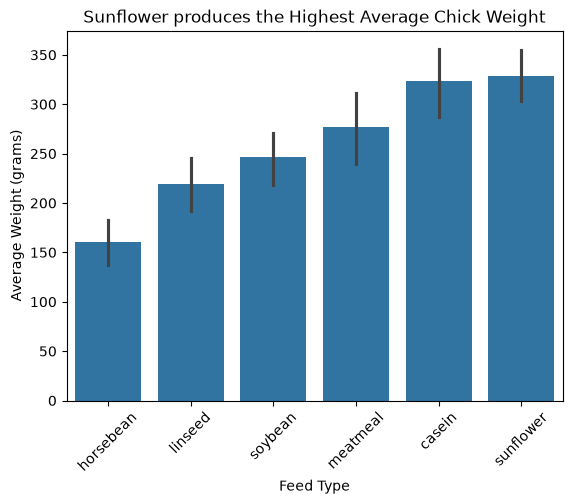

In [10]:
feed_order = chicks.groupby("feed")["weight"].mean().sort_values().index
sns.barplot(data=chicks, x="feed", y="weight", order=feed_order)
plt.title("Sunflower produces the Highest Average Chick Weight")
plt.xlabel("Feed Type")
plt.ylabel("Average Weight (grams)")
plt.xticks(rotation=45)
plt.show()

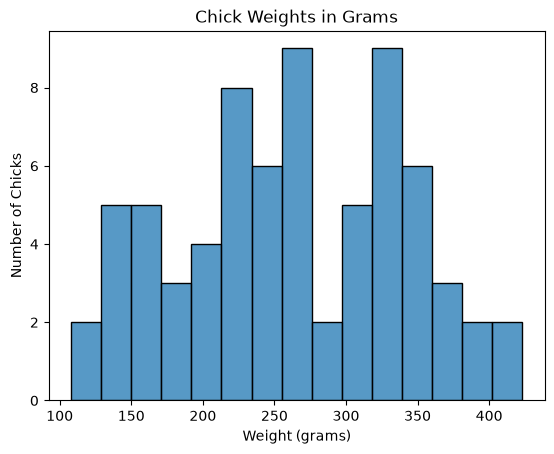

In [12]:
sns.histplot(data=chicks, x="weight", bins=15)
plt.title("Chick Weights in Grams")
plt.xlabel("Weight (grams)")
plt.ylabel("Number of Chicks")
plt.show()

In [13]:
museum = pd.read_csv("museum_visitors.csv")
display(museum.head())
print(museum.columns)

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


Index(['Date', 'Avila Adobe', 'Firehouse Museum', 'Chinese American Museum',
       'America Tropical Interpretive Center'],
      dtype='str')


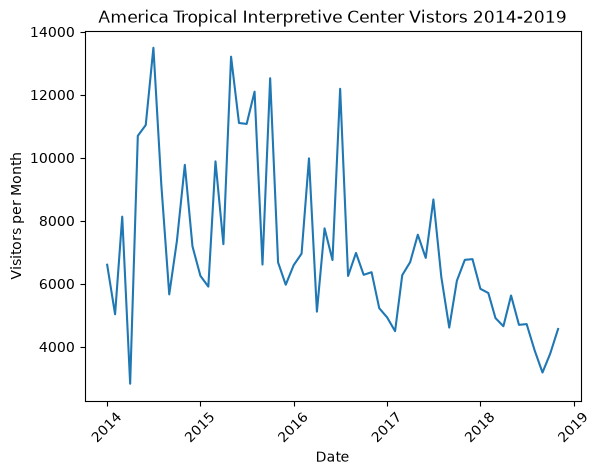

In [20]:
museum["Date"] = pd.to_datetime(museum["Date"])

sns.lineplot(data=museum, x="Date", y="America Tropical Interpretive Center")

plt.title("America Tropical Interpretive Center Vistors 2014-2019")
plt.xlabel("Date")
plt.ylabel("Visitors per Month")
plt.xticks(rotation=45)
plt.show()

Trend observation: Vistors were typically peaking halfway through the year but after 2016 we no longer saw a high increase of visitors and with 2017 and on we see a continuing decline of visitors.

In [21]:
sales = pd.read_csv("sales_clean.csv")
print(sales.shape)
display(sales.head())
print(sales.columns)

(292, 7)


,order_id,date,product,price,qty,zip,return_flag
0,1254,2026-04-06,mug,11.36,4,60614,False
1,1057,2026-05-30,charger,14.79,3,30303,False
2,1150,2026-05-06,mug,5.50,1,10001,False
3,1066,2026-05-30,notebook,37.53,1,98101,False
4,1114,2026-04-06,webcam,45.59,4,90405,False


Index(['order_id', 'date', 'product', 'price', 'qty', 'zip', 'return_flag'], dtype='str')


In [23]:
sales["revenue"]=sales["price"]*sales["qty"]
display(sales.head())

,order_id,date,product,price,qty,zip,return_flag,revenue
0,1254,2026-04-06,mug,11.36,4,60614,False,45.44
1,1057,2026-05-30,charger,14.79,3,30303,False,44.37
2,1150,2026-05-06,mug,5.50,1,10001,False,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,False,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,False,182.36


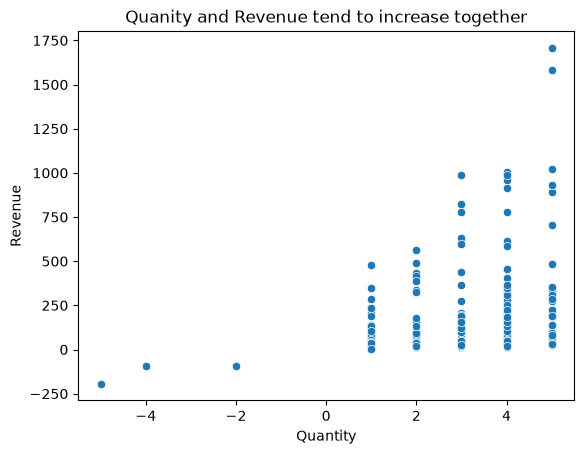

In [27]:
sns.scatterplot(data=sales,x="qty",y="revenue")
plt.title("Quanity and Revenue tend to increase together")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

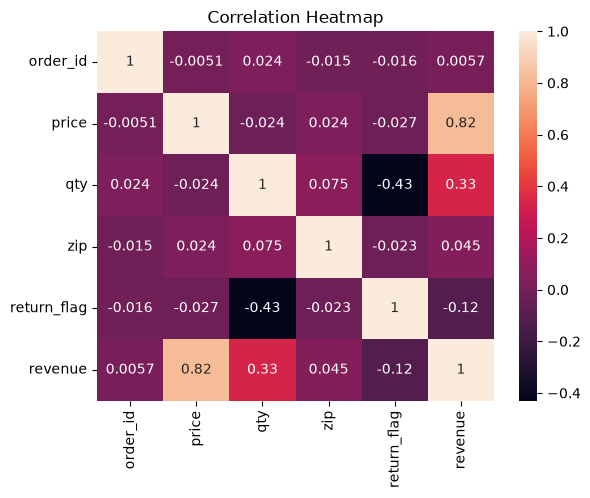

In [29]:
sns.heatmap(sales.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

The strongest correlation is between price and revenue at 0.82, this is also what we saw in module 4. The sale of a higher priced item generated more revenue.

Null Hypothesis: Average chick weight differences between sunflower seed fed chicks and horsebean fed chicks have no significance and happened by chance.

In [30]:
from scipy.stats import ttest_ind
sunflower=chicks[chicks["feed"]=="sunflower"]["weight"]
horsebean= chicks[chicks["feed"]=="horsebean"]["weight"]
ttest_ind(sunflower, horsebean)

TtestResult(statistic=np.float64(8.848346742516636), pvalue=np.float64(2.3743507676837164e-08), df=np.float64(20.0))

Analysis: The effect size is about 168.72 grams, the p value is .0000000237 which is far below 0.05. and the t-test is 8.84. Due to these results, we reject the null hypothesis as the difference is not random and is  significant. One caution is the small sample size of number of chicks and where the chicks are sourced. We cannot answer if this same result can be found at other farms.

The charts created are honest because the data was not altered in any way. The data was not cut off in any way. The visuals are clear and easy to understand and the title states a clear observation.

AI USe: Chat Gpt
- needed help opening a new miniforge to import seaborn
- asked for assistance in importing the data correctly in Jupyter, did not seem to be loading and it explained if side has a * that it is still loading.
-asked for explanation on a heatmap